In [1]:
#Python v3.10.11
#Import necessary packages

import os
import sys
import numpy as np
import string

import seaborn as sns
import matplotlib.pyplot as plt

import scipy
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, train_test_split

import warnings
warnings.simplefilter(action='ignore')
import pandas as pd

sys.path.append('functions')

from death_prediction_functions import time_to_death_grouped, cross_validation, train_nn, generate_nn_pred, train_ae
from gene_analysis_functions import get_great, get_cistrome, get_pos

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
'''
Format healthspan data for neural network
'''

os.chdir('/Users/samanderson/Desktop/pellegrini_lab_research/raw_data')
data = pd.read_excel('healthspan_aging_data.xlsx')
data = data.dropna()

#create 'death clock' column
data['death_wks'] = data['death_mo'].apply(lambda x: x*4.3)
data['age'] = data['time_point_in_study_weeks'].apply(lambda x: x+12)
data['death_clock'] = data['death_wks'] - data['age']

data = data.drop(columns=['animal', 'DAI', 'no_recorded_intervals', 'cohort', 'partner', 'age', 'death_wks', 'death_mo'])

#removes negatives, only one observed in entire dataset anyways though
data = data[data.death_clock != 0]

#split categorical into columns so that a linear relationship is not established
data['strain'] = data['strain'].replace('CD1', '0,1')
data['strain'] = data['strain'].replace('C57BL6', '1,1')
data['strain'] = data['strain'].replace('Sv129', '1,0')

data[['C57BL6J or Sv129Ev', 'CD1 or C57BL6J']] = data['strain'].str.split(',', expand=True)
data[['C57BL6J or Sv129Ev', 'CD1 or C57BL6J']]

data['C57BL6J or Sv129Ev'] =  data['C57BL6J or Sv129Ev'].astype(int)
data['CD1 or C57BL6J'] = data['CD1 or C57BL6J'].astype(int)
data = data.drop(columns=['strain'])

#convert strings to strain indicators
data['rank'] = data['rank'].replace('sub', 0)
data['rank'] = data['rank'].replace('u_d', 1)
data['rank'] = data['rank'].replace('dom', 2)

X = data.drop('death_clock', axis=1)
y = data['death_clock']

X
y

0       69.413333
1       65.413333
2       57.413333
3       49.413333
4       41.413333
          ...    
3395    72.869000
3396    64.869000
3397    48.869000
3398    32.869000
3399    16.869000
Name: death_clock, Length: 3391, dtype: float64

In [3]:
'''
Normalize the data
'''

X = X.rename(columns={'rank': 'Rank'})
X_norm = X.drop(columns=['C57BL6J or Sv129Ev', 'CD1 or C57BL6J', 'Rank'])
X_norm = (X_norm-X_norm.mean())/X_norm.std() #Z-score = (Observed - Expected) / Standard Deviation

X_norm['C57BL6J or Sv129Ev'] = X['C57BL6J or Sv129Ev'] #dummy encoding
X_norm['CD1 or C57BL6J'] = X['CD1 or C57BL6J']
X_norm['Rank'] = X['Rank']
X_norm['time_point_in_study_weeks'] = data['time_point_in_study_weeks']

X = X_norm #since X being the input data name is common practice
X

,aggression_index,FI_kcal,BW_g,FM_g,FFM_g,GLU_mg/dL,time_point_in_study_weeks,C57BL6J or Sv129Ev,CD1 or C57BL6J,Rank
0,1.351078,1.373268,0.370971,0.103955,0.552144,0.571599,0,0,1,2
1,1.351078,0.281961,0.037180,-0.591289,0.698571,-0.328829,4,0,1,2
2,1.351078,2.028052,2.272571,2.200869,1.828153,0.121385,12,0,1,2
3,1.351078,-0.809345,2.717626,2.616524,2.028619,3.030461,20,0,1,2
4,1.351078,1.700660,2.768201,2.543831,2.321473,6.355118,28,0,1,2
...,...,...,...,...,...,...,...,...,...,...
3395,0.689086,-0.154561,-0.276382,-0.212912,-0.146872,0.363808,52,1,1,1
3396,0.689086,-0.481953,0.745222,1.173847,0.088458,-0.294197,60,1,1,1
3397,0.689086,0.500223,0.542924,0.802926,0.029189,-0.051774,76,1,1,1
3398,0.689086,-0.918476,0.826141,1.220445,0.405717,0.779390,92,1,1,1


Epoch: 0 and loss: 279.7532653808594
Epoch: 10 and loss: 0.45206940174102783
Epoch: 20 and loss: 0.2945171296596527
Epoch: 30 and loss: 0.19126759469509125
Epoch: 40 and loss: 0.16519267857074738
Epoch: 50 and loss: 0.15819695591926575
Epoch: 60 and loss: 0.1620350033044815
Epoch: 70 and loss: 0.16374416649341583
Epoch: 80 and loss: 0.1633700728416443
Epoch: 90 and loss: 0.1668965220451355
Epoch: 100 and loss: 0.17202436923980713


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'aggression_index'),
  Text(1, 0, 'FI_kcal'),
  Text(2, 0, 'BW_g'),
  Text(3, 0, 'FM_g'),
  Text(4, 0, 'FFM_g'),
  Text(5, 0, 'GLU_mg/dL'),
  Text(6, 0, 'time_point_in_study_weeks'),
  Text(7, 0, 'C57BL6J or Sv129Ev'),
  Text(8, 0, 'CD1 or C57BL6J'),
  Text(9, 0, 'Rank')])

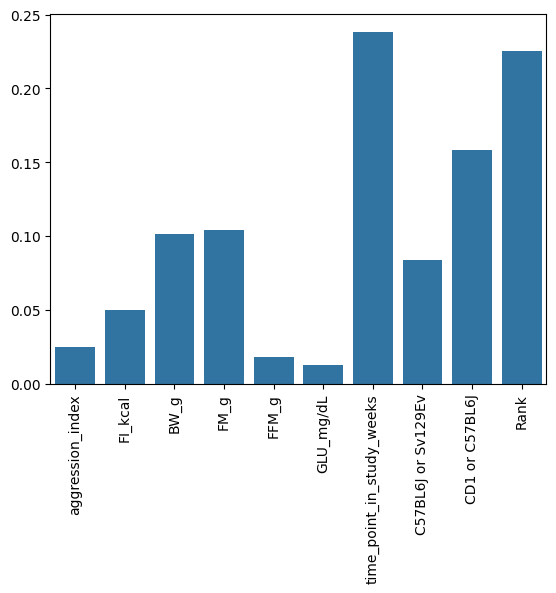

In [32]:
#implement autoencoder to determine significance of different traits in underlying model accuracy
#indicates that the model is capturing the significance of blood glucose especially well
#I think this provides an inferior set of information that provided by simply removing one trait and iterating
#so I doubt we'll mention it in the paper. Still an interesting exercise nonetheless.

trait_loss = train_ae(X, 32, 106)
sns.barplot(trait_loss)
plt.xticks(rotation=90)

In [ ]:
'''
Determine differences in model accuracy depending on which trait is removed
'''

epochs = 106
batch_size = 32

trait_loss_w = {}
trait_loss_wout = {}
trait_loss_avg = {}

n_iterations = 5 #for cross valu
n_varients = 2 #with and without time

n = 0
working_data = X.copy()
status = 'with_time'
while n < n_varients:
   for column in working_data:

      #Drop unused column
      #Want to drop both strain values at once
      if 'C57BL6J or Sv129Ev' in column:
         continue
      elif 'CD1 or C57BL6J' in column:
         print(f'\nTrait: Strain')
         working_data = working_data.drop(columns = [column, 'C57BL6J or Sv129Ev'])
         column = 'Strain'
      else:
         print(f'\nTrait: {column}')
         working_data = working_data.drop(columns = [column])

      #run model
      all_approx, all_actual, all_losses = cross_validation(working_data, y, batch_size, epochs, n_iterations)
      
      #calculate average loss by trait
      trait_loss_avg[f'{column}_{status}'] = sum(all_losses) / len(all_losses)

      #get all losses for each trait and add to appropriate dictionary
      if status == 'with_time':
         trait_loss_w[column] = all_losses
      else:
         trait_loss_wout[column] = all_losses
      
   status = 'no_time'
   working_data = X.drop(columns = 'time_point_in_study_weeks')
   n+=1

trait_loss_avg

In [ ]:
'''
Format strain-trait value correctly
'''

sum_data = pd.DataFrame()
sum_data['trait_avg_loss'] = trait_loss_avg.values()
sum_data['trait_name'] = trait_loss_avg.keys()

sum_data.loc[(sum_data['trait_name'] == 'CD1 or C57BL6J'), 'trait_name'] = 'strain'

'''
Determine if differences in accuracy are significant
'''

n_datapoints = X.shape[0]//n_iterations+1

loss_notime = 0
loss_time = 0

k = 0
trait_Z = {}

for key in trait_loss_avg.keys():
    non_trait_loss = []
    for key2 in trait_loss_avg.keys():
        if key2 != key: #so if key2 is not the trait being tested
            non_trait_loss.append(trait_loss_avg[key2])
        else:
            trait_sigma = np.std(trait_loss_avg[key]) / np.sqrt(n_datapoints) #std/sqrt(n_samples)
            trait_mean = np.mean(trait_loss_avg[key]) #avg for trait
            
    non_trait_sigma = np.std(non_trait_loss) / np.sqrt(len(non_trait_loss)) #std/sqrt(n_samples)
    non_trait_mean = np.mean(non_trait_loss)

    Z = (trait_mean - non_trait_mean) / np.sqrt(trait_sigma**2 + non_trait_sigma**2) #compare z scores of populations
    trait_Z[key] = Z

dict_as_ordered = []
for trait in sum_data['trait_name']:
    p_values = scipy.stats.norm.sf(abs(trait_Z[trait]))*2
    dict_as_ordered.append(p_values)

sum_data['trait_corr_p_val'] = dict_as_ordered
sum_data

In [ ]:
'''
Cross Validation w/ all traits
'''

epochs = 106
batch_size = 32
sum_approx, sum_actual, sum_losses = cross_validation(X, y, batch_size, epochs, n_iterations)

'''
Display cross validation results as a graph using the data from all of the iterations combined
'''

val_predictions = pd.DataFrame()
val_predictions['actual'] = sum_actual
val_predictions['approximation'] = sum_approx

val_predictions = val_predictions.apply(pd.to_numeric)

avg_loss = sum(sum_losses) / len(sum_losses)
corr = stats.kendalltau(x=val_predictions['actual'], y=val_predictions['approximation'])

In [ ]:
'''
Create plots showing model accuracy
'''

#distinguish subplots
w_time = sum_data[sum_data.apply(lambda r: r.str.contains('with_time', case=False).any(), axis=1)]
wout_time = sum_data[sum_data.apply(lambda r: r.str.contains('no_time', case=False).any(), axis=1)] 

#get rid of un-needed parts of trait names
w_time['trait_name'] = w_time['trait_name'].map(lambda x: x[:-10]) 
wout_time['trait_name'] = wout_time['trait_name'].map(lambda x: x[:-8]) 

#get formatted Loss
loss_clipped = '{0:.3f}'.format(avg_loss)

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))
len_traits = [i for i in range(1,9)]

w_time_vals = list(w_time['trait_avg_loss'].values)
w_category = ['with time']*len(w_time_vals) 
w_names = list(w_time['trait_name'].values)

wout_time_vals = list(wout_time['trait_avg_loss'].values)
wout_category = ['without time']*len(wout_time_vals)
wout_names = list(wout_time['trait_name'].values)

both_time = pd.DataFrame()
both_time['loss_values'] = wout_time_vals + w_time_vals
both_time['trait'] = wout_names + w_names
both_time['category'] = wout_category + w_category
both_time = both_time.replace('time_point_in_study_weeks', 'time_point')

#1
sns.barplot(data = both_time, x = 'trait', y = 'loss_values', hue = 'category', palette='viridis_r', ax=axs[0,0])
axs[0,0].axhline(float(loss_clipped), color='red', linestyle='--')
axs[0,0].tick_params(labelrotation=90)
axs[0,0].set_ylabel('loss')
axs[0,0].set_ylim([10, 30])
axs[0,0].set_yticks([10, 15, 20, 25, 30])
axs[0,0].set_title('avg loss by trait', size=12)

#2

sns.kdeplot(data = trait_loss_wout, hue=None, palette='viridis_r', ax=axs[0,1])
axs[0,1].set_xlabel('loss')
axs[0,1].set_yticks([])
axs[0,1].set_ylabel('probability')
axs[0,1].tick_params(labelrotation=90)
axs[0,1].set_title('probability density by trait (without time)', size=12)

#3 - regplot for prediction vs actual

'''
axs[1,0].plot(np.unique(val_predictions['actual']), np.poly1d(np.polyfit(val_predictions['actual'], 
                val_predictions['approximation'], 1))(np.unique(val_predictions['actual'])), 
                color='orange')
'''

sns.regplot(data=None, x=val_predictions['actual'], y=val_predictions['approximation'], 
                color='red', order=4, ax=axs[1,0], scatter_kws={'alpha':0.1, 'color':'blue'})

sum_actual = [float(x) for x in sum_actual]
sum_approx = [float(x) for x in sum_approx]

x_max = 150
axs[1,0].set_xlim([0,x_max])
axs[1,0].set_title('actual vs prediction', size=12)
axs[1,0].text(s=f'Smooth L1 Loss: {loss_clipped}', x=x_max//4, y=8, size=12)
               

#4 - regplot for accuracy vs time to death
accuracy_over_time = [np.mean(i) for i in zip(sum_actual,sum_approx)]

sns.kdeplot(data=None, x=val_predictions['actual'], y=sum_losses, 
                color='blue', order=2, ax=axs[1,1], fill=True)

axs[1,1].set_xlim([0,150])
axs[1,1].set_ylim([0,60])


axs[1,1].set_title('actual vs loss')
axs[1,1].set_ylabel('loss')

axs = axs.flat

for n, ax in enumerate(axs):
    ax.text(-0.1, 1.1, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=15, weight='bold')

plt.tight_layout()

In [ ]:
'''
Train the whole model
'''

print('\nBeginning Full Training Cycle\n')

epochs = 106
batch_size = 32

#Train the model without a validation set
model = train_nn(X, y, batch_size, epochs)

In [ ]:
#import the methylation-phenotype cohort
data_2 = pd.read_excel('methylation_phenotype_encoded.xlsx', index_col=0)
data_2 = data_2.dropna()
sep = 55

trait_data = data_2.iloc[:sep]

In [ ]:
'''
Import, format, and normalize the phenotype-methylation cohort
'''

group_baseline = ['Baseline_food_g', 'Baseline_BW', 'Baseline_FM_g', 'Baseline_FFM_g', 'Baseline_GLU']
group_w4 = ['w4_stress_food_g', 'w4_stress_BW', 'w4_stress_FM_g', 'w4_stress_FFM_g', 'w4_stress_GLU']
group_M2 = ['M2_poststress_food_g', 'M2_poststress_BW', 'M2_poststress_FM_g', 'M2_poststress_FFM_g', 'M2_poststress_GLU']
group_M4 = ['M4_poststress_food_g', 'M4_poststress_BW', 'M4_poststress_FM_g', 'M4_poststress_FFM_g', 'M4_poststress_GLU']
group_M6 = ['M6_poststress_food_g', 'M6_poststress_BW', 'M6_poststress_FM_g', 'M6_poststress_FFM_g', 'M6_poststress_GLU']
group_M8 = ['M8_poststress_food_g', 'M8_poststress_BW', 'M8_poststress_FM_g', 'M8_poststress_FFM_g', 'M8_poststress_GLU']
group_M10 = ['M10_poststress_food_g', 'M10_poststress_BW', 'M10_poststress_FM_g', 'M10_poststress_FFM_g', 'M10_poststress_GLU']
group_M12 = ['M12_poststress_food_g', 'M12_poststress_BW', 'M12_poststress_FM_g', 'M12_poststress_FFM_g', 'M12_poststress_GLU']

groups = [group_baseline, group_w4, group_M2, group_M4, group_M6, group_M8, group_M10, group_M12]

FI_kcal = []
BW_g = []
FM_g = []
FFM_g = []
GLU_mg = []

for g in groups:
    for f in trait_data.loc[g[0]]:
        FI_kcal.append(round(f*7.716179, 2)) #converts grams to kilocal
    for b in trait_data.loc[g[1]]:
        BW_g.append(b)
    for fm in trait_data.loc[g[2]]:
        FM_g.append(fm)
    for ffm in trait_data.loc[g[3]]:
        FFM_g.append(ffm)
    for glu in trait_data.loc[g[4]]:
        GLU_mg.append(glu)

working_data = pd.DataFrame()

#format data

C57BL6J_or_Sv129Ev = list(trait_data.loc['C57BL6J or Sv129Ev?'])*8
CD1_or_C57BL6J = list(trait_data.loc['CD1 or C57BL6J?'])*8 
aggression_index = list(trait_data.loc['Aggression index'])*8
rank = list(trait_data.loc['Rank'])*8

working_data['C57BL6J or Sv129Ev'] = C57BL6J_or_Sv129Ev
working_data['CD1 or C57BL6J'] = CD1_or_C57BL6J
working_data['Rank'] = rank
working_data['aggression_index'] = aggression_index

working_data['FI_kcal'] = FI_kcal
working_data['BW_g'] = BW_g
working_data['FM_g'] = FM_g
working_data['FFM_g'] = FFM_g
working_data['GLU_mg'] = GLU_mg

working_data = working_data.dropna()
working_data_norm = working_data.drop(columns=['C57BL6J or Sv129Ev', 'CD1 or C57BL6J', 'Rank'])
working_data_norm = (working_data_norm-working_data_norm.mean())/working_data_norm.std() #z score

working_data_norm['C57BL6J or Sv129Ev'] = working_data['C57BL6J or Sv129Ev']
working_data_norm['CD1 or C57BL6J'] = working_data['CD1 or C57BL6J']
working_data_norm['Rank'] = working_data['Rank']

working_data = working_data_norm

#add the time values

rep = 46 #since you add each baseline mouse value, then each w4, etc., this works. 46 is number of mice
group = ['Baseline'] * rep + ['w4'] * rep + ['M2'] * rep + ['M4'] * rep + ['M6'] * rep + ['M8'] * rep + ['M10'] * rep + ['M12'] * rep
working_data['group'] = group

group_data = working_data.copy()

#replace each timepoint with same format as train dataset, in weeks, with 0 representing the start of the study
working_data['group'] = working_data['group'].replace('Baseline', 0)
working_data['group'] = working_data['group'].replace('w4', 4)
working_data['group'] = working_data['group'].replace('M2', 8.6)
working_data['group'] = working_data['group'].replace('M4', 17.2)
working_data['group'] = working_data['group'].replace('M6', 25.8)
working_data['group'] = working_data['group'].replace('M8', 34.4)
working_data['group'] = working_data['group'].replace('M10', 43)
working_data['group'] = working_data['group'].replace('M12', 52)

working_data = working_data.rename(columns={'GLU_mg': 'GLU_mg/dL', 'group' : 'time_point_in_study_weeks'})
working_data = working_data[X.columns]
working_data

In [ ]:
'''
Apply the NN model to the phenotype-methylation cohort
'''

#Apply the model to this data
predictions = generate_nn_pred(model, working_data)
working_data['Predicted time until death'] = predictions
group_data['Predicted time until death'] = predictions

#working_data.to_excel('time_until_death_predictions.xlsx')

In [ ]:
'''
prep dataframes for plotting
'''

working_data['strain'] = working_data['CD1 or C57BL6J'] + working_data['C57BL6J or Sv129Ev']*2
working_data['strain'] = working_data['strain'].replace(1, 'CD1')
working_data['strain'] = working_data['strain'].replace(2, 'Sv129Ev')
working_data['strain'] = working_data['strain'].replace(3, 'C57BL6J')

working_data['Rank'] = working_data['Rank'].replace(0, 'sub')
working_data['Rank'] = working_data['Rank'].replace(1, 'u_d')
working_data['Rank'] = working_data['Rank'].replace(2, 'dom')


groups = ['Baseline', 'w4']
for i in range(2, 13, 2):
  groups.append('M' + str(i))

group_data = time_to_death_grouped(group_data, 'group')
group_data = group_data.reindex(groups)

In [ ]:
#Run computations for plot assessing categorical significance in time to death
#Runs properly in 3.8.5, ugly in 3.11.7 ... don't ask me why

'''
Plot significance of different categories in affecting time to death
'''

##

fig, axs = plt.subplots(2,2, figsize=(15,10))

#plot 1

group_indices = [x for x in range(0,8)]
sns.regplot(data=None, x=group_indices, y=group_data['Predicted time until death'], ax=axs[0,0],
            scatter=False, line_kws={'color': 'lightcoral', 'lw':2}, order=4, ci=None)

sns.scatterplot(data = None, x = groups, y = group_data['Predicted time until death'], ax=axs[0,0], 
                hue=group_data['Predicted time until death'], palette='viridis_d', legend=False)

axs[0,0].tick_params(labelrotation=90)
axs[0,0].set_xlabel('group', size=15)
axs[0,0].set_ylabel('predicted time until death', size=15)

#plot 2

sns.violinplot(data=None, x=working_data['strain'], y=working_data['Predicted time until death'], 
            ax=axs[0,1], hue=working_data['strain'], palette='viridis', legend=False)

axs[0,1].set_xlabel('strain', size=15)
axs[0,1].set_ylabel('predicted time until death', size=15)


#get significance and add to plot
strain_corr = stats.kendalltau(x=working_data['strain'], y=working_data['Predicted time until death'])
strain_corr = '{0:.3f}'.format(strain_corr[1])
axs[0,1].set_title(f'p value: {strain_corr}', y=-0.01, size=12)

#plot 3

sns.violinplot(data=None, x=working_data['Rank'], y=working_data['Predicted time until death'],
            ax=axs[1,0], hue=working_data['Rank'], palette='viridis', legend=False)

axs[1,0].set_xlabel('rank', size=15)
axs[1,0].set_ylabel('predicted time until death', size=15)

#determine significance of strain and rank respectively, and add these to their respective plots
rank_corr = stats.kendalltau(x=working_data['Rank'], y=working_data['Predicted time until death'])
rank_corr = '{0:.3f}'.format(rank_corr[1])
axs[1,0].set_title(f'p value: {rank_corr}', y=-0.01, size=12)

########################

#plot 4 computations

heatmap_data = working_data[['strain', 'Rank', 'Predicted time until death']]
heatmap_data = heatmap_data.pivot_table(values='Predicted time until death', index='strain', 
                      columns='Rank', fill_value=0)


heatmap_data = heatmap_data[['dom', 'u_d', 'sub']]
heatmap_data = heatmap_data.reindex(['C57BL6J', 'Sv129Ev', 'CD1'])
#C57, Sv, CD1

##
#determine significance of each heatmap subunit
##

working_data['strain'] = working_data['strain'].replace('CD1', 1)
working_data['strain'] = working_data['strain'].replace('Sv129Ev', 2)
working_data['strain'] = working_data['strain'].replace('C57BL6J', 3)

working_data['Rank'] = working_data['Rank'].replace('sub', 0)
working_data['Rank'] = working_data['Rank'].replace('u_d', 1)
working_data['Rank'] = working_data['Rank'].replace('dom', 2)

# 1 = CD1
# 2 = Sv129
# 3 = C57

#Get significance of rank for each strain

C57 = working_data.loc[working_data['strain'] == 3]
C57 = C57.drop(columns=['strain'])

C57_rank_corr = stats.kendalltau(x=C57['Rank'], y=C57['Predicted time until death'])
C57_rank_corr = '{0:.3f}'.format(C57_rank_corr[1])

#

Sv129 = working_data.loc[working_data['strain'] == 2]
Sv129 = Sv129.drop(columns=['strain'])

Sv129_rank_corr = stats.kendalltau(x=Sv129['Rank'], y=Sv129['Predicted time until death'])
Sv129_rank_corr = '{0:.3f}'.format(Sv129_rank_corr[1])

#

CD1 = working_data.loc[working_data['strain'] == 1]
CD1 = CD1.drop(columns=['strain'])

CD1_rank_corr = stats.kendalltau(x=CD1['Rank'], y=CD1['Predicted time until death'])
CD1_rank_corr = '{0:.3f}'.format(CD1_rank_corr[1])

##

C57_n_dom = int(C57[C57['Rank'] == 2].shape[0]/8)
C57_n_neither = int(C57[C57['Rank'] == 1].shape[0]/8)
C57_n_sub = int(C57[C57['Rank'] == 0].shape[0]/8)

C57_sum = C57_n_dom + C57_n_neither + C57_n_sub

#

Sv129_n_dom = int(Sv129[Sv129['Rank'] == 2].shape[0]/8)
Sv129_n_neither = int(Sv129[Sv129['Rank'] == 1].shape[0]/8)
Sv129_n_sub = int(Sv129[Sv129['Rank'] == 0].shape[0]/8)

Sv129_sum = Sv129_n_dom + Sv129_n_neither + Sv129_n_sub

#

CD1_n_dom = int(CD1[CD1['Rank'] == 2].shape[0]/8)
CD1_n_neither = int(CD1[CD1['Rank'] == 1].shape[0]/8)
CD1_n_sub = 0

CD1_sum = CD1_n_dom + CD1_n_neither + CD1_n_sub

##

n_animals = [[f'n={C57_n_dom}', f'n={C57_n_neither}', f'n={C57_n_sub}', f'n={C57_sum}'],
             [f'n={Sv129_n_dom}', f'n={Sv129_n_neither}', f'n={Sv129_n_sub}', f'n={Sv129_sum}'],
             [f'n={CD1_n_dom}', f'n={CD1_n_neither}', 'n=0', f'n={CD1_sum}']]

#C57, Sv, CD1

pvals_rank_strain = [C57_rank_corr, Sv129_rank_corr, CD1_rank_corr]
heatmap_data['p_val'] = pvals_rank_strain
heatmap_data = heatmap_data.astype(float)

heatmap_pretty = heatmap_data

heatmap_pretty['dom'] = heatmap_pretty['dom'].astype(int)
heatmap_pretty['u_d'] = heatmap_pretty['u_d'].astype(int)
heatmap_pretty['sub'] = heatmap_pretty['sub'].astype(int)

heatmap_pretty = heatmap_pretty.astype(str)
heatmap_pretty = heatmap_pretty.values

#plot 4a

#number of animals
sns.heatmap(data=heatmap_data, annot=n_animals, 
            annot_kws={'va':'top', 'fontsize': 10}, 
            fmt='', cbar=False, ax=axs[1,1])

#plot 4b

#avg time to death
sns.heatmap(data=heatmap_data, annot=heatmap_pretty, 
            annot_kws={'va':'bottom', 'fontsize': 12}, 
            fmt='', cbar=False, ax=axs[1,1])

#plot 4c

#formatting
sns.heatmap(data=heatmap_data, annot=False, linewidth=.5, 
            cmap='viridis', ax=axs[1,1])

axs[1,1].set_xlabel('rank', size=15)
axs[1,1].set_ylabel('strain', size=15)


#Overall figure stuff

plt.rc('axes', titlesize=15)     # fontsize of the axes title
plt.rc('axes', labelsize=12)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=10)    # fontsize of the tick labels
plt.rc('ytick', labelsize=10)    # fontsize of the tick labels

axs = axs.flat

for n, ax in enumerate(axs):
    ax.text(-0.1, 1.1, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=15, weight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.5, hspace=0.5)

In [ ]:
'''
calculate a weighted average for each animal using the outputted time until death predictions
'''

n = 0
weights = [2, 5, 8, 11, 14, 17, 20, 23] #since later weights are closer in timepoint to methylation
y = []

while n < rep:
  m = 0
  weight_avg = []
  while m < len(weights): 
    weight_avg.append(predictions[(rep*m)+n][0])
    m+=1
  y.append(np.average(weight_avg, weights=weights))
  n+=1

In [ ]:
'''
Decrease number of probes using elastic band model + verify elastic band model's accuracy
'''

meth_data = data_2[sep:]

#split data: shuffles every time any of these are used
test_size = 6
X_train, X_test, y_train, y_test = train_test_split(meth_data.T, y, test_size=test_size/46) #=6 test animals

#identify hyperparameters to optimize, and train these
param_grid = {'alpha' : np.arange(0, 1, 0.1), 'l1_ratio' : np.arange(0, 1, 0.1)}

#perform cross validation to optimize hyperparameters, then test this
elastic_optimized = GridSearchCV(ElasticNet(), param_grid, cv=5, scoring='neg_mean_squared_error') #5 iterations of 8 animals
elastic_optimized.fit(X_train, y_train)

mean_vals = []
for iter in range(0,test_size): #test on each remaining animal

    y_pred = elastic_optimized.predict(X_test)
    mean_vals.append(mean_absolute_error(y_test, y_pred))

print(f'mean absolute error: {np.mean(mean_vals)}') #avg of avg is fine here due to equivalent sizes

#retrain model on all inputs
elastic_optimized.fit(meth_data.T, y)

#select probes maintained by the model, and add them to the appropriate format
output = meth_data.copy()
output['coef'] = elastic_optimized.best_estimator_.coef_
output = output[output.coef != 0]
output

In [ ]:
#get ideal hyperparameters
elastic_optimized.best_estimator_

In [ ]:
#Add chromosome positions and associated genes to dataframe

%reload_ext autoreload
working_data = output.copy()

ref_data = pd.read_excel('mm39_formatted_manifest.xlsx', index_col=0)
probe_df = get_pos(working_data, ref_data)
probe_df = get_great(probe_df)

#probe_df.to_excel('age_associated_probes.xlsx')
probe_df

In [ ]:
get_cistrome(probe_df, fig_w=5000, fig_h=1800, check_pval=False, top_10k=True)